In [23]:
# Load and inspect the Egencia Analytics Case Study dataset
import pandas as pd
import numpy as np
from datetime import datetime

# Load the dataset
df = pd.read_csv('Egencia Analytics Case Study.csv', encoding='UTF-8-SIG')

# Basic inspection
print("Dataset shape:", df.shape)
print("\
Column names and types:")
print(df.dtypes)
print("\
First few rows:")
print(df.head())

Dataset shape: (299999, 14)
Column names and types:
BOOKING_ID                int64
BOOKING_TYPE_NAME        object
PRODUCT_NAME             object
PLATFORM                 object
CUSTOMER_ID               int64
TRAVELER_ID               int64
BOOKING_DATE             object
TRAVEL_START             object
TRAVEL_END               object
INVOICE_DATE             object
ONLINE_PURCHASE_FLAG       bool
BOOKING_AMOUNT          float64
SAVINGS_AMOUNT          float64
TRANSACTION_COUNT         int64
dtype: object
First few rows:
   BOOKING_ID BOOKING_TYPE_NAME PRODUCT_NAME PLATFORM  CUSTOMER_ID  \
0   159585350           Reserve          Car  Desktop            0   
1   128623600            Cancel          Car  Desktop            0   
2    16125082           Reserve          Car   Mobile            0   
3   129001472           Reserve          Car  Desktop            0   
4    64792032           Reserve          Car  Desktop            0   

   TRAVELER_ID BOOKING_DATE TRAVEL_START  TRAVEL_

In [24]:
# Check for missing values and data quality issues
print("Missing values per column:")
print(df.isnull().sum())
print("\
Unique values in categorical columns:")
print("BOOKING_TYPE_NAME:", df['BOOKING_TYPE_NAME'].unique())
print("PRODUCT_NAME:", df['PRODUCT_NAME'].unique())
print("PLATFORM:", df['PLATFORM'].unique())
print("\
Duplicate rows:", df.duplicated().sum())
print("\
Booking amount statistics:")
print(df['BOOKING_AMOUNT'].describe())

Missing values per column:
BOOKING_ID                   0
BOOKING_TYPE_NAME            0
PRODUCT_NAME                 0
PLATFORM                     2
CUSTOMER_ID                  0
TRAVELER_ID                  0
BOOKING_DATE                 0
TRAVEL_START                 3
TRAVEL_END                   3
INVOICE_DATE            102885
ONLINE_PURCHASE_FLAG         0
BOOKING_AMOUNT               0
SAVINGS_AMOUNT               0
TRANSACTION_COUNT            0
dtype: int64
Unique values in categorical columns:
BOOKING_TYPE_NAME: ['Reserve' 'Cancel' 'Purchase' 'Refund' 'Exchange' 'Partial Refund' 'Void']
PRODUCT_NAME: ['Car' 'Hotel' 'Air']
PLATFORM: ['Desktop' 'Mobile' nan]
Duplicate rows: 0
Booking amount statistics:
count    2.999990e+05
mean     1.377284e+03
std      4.474496e+04
min     -1.056671e+05
25%      2.460950e+02
50%      6.500400e+02
75%      1.485770e+03
max      2.442042e+07
Name: BOOKING_AMOUNT, dtype: float64


In [25]:
# Clean the dataset
# 1. Convert date columns to datetime format
date_columns = ['BOOKING_DATE', 'TRAVEL_START', 'TRAVEL_END', 'INVOICE_DATE']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce')

print("Date conversion completed")
print("Date columns after conversion:")
for col in date_columns:
    print(f"{col}: {df[col].dtype}")

Date conversion completed
Date columns after conversion:
BOOKING_DATE: datetime64[ns]
TRAVEL_START: datetime64[ns]
TRAVEL_END: datetime64[ns]
INVOICE_DATE: datetime64[ns]


In [26]:
# Handle missing values and outliers
# 1. Fill missing PLATFORM values with 'Unknown'
df['PLATFORM'].fillna('Unknown', inplace=True)
df['ONLINE_PURCHASE_FLAG'] = df['ONLINE_PURCHASE_FLAG'].astype(bool)
# 2. For missing TRAVEL_START and TRAVEL_END, we'll keep them as NaN since they might be legitimate missing data
# 3. INVOICE_DATE has many missing values - this is likely normal for some booking types



In [27]:
# Data preprocessing and date conversion
df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'])
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'])
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'])

# Extract year-month for time series analysis
df['Year_Month'] = df['BOOKING_DATE'].dt.to_period('M')
df['Year'] = df['BOOKING_DATE'].dt.year
df['Quarter'] = df['BOOKING_DATE'].dt.quarter

# Basic statistics
print("Date range:", df['BOOKING_DATE'].min(), "to", df['BOOKING_DATE'].max())
print("Booking types:", df['BOOKING_TYPE_NAME'].value_counts())
print("Product types:", df['PRODUCT_NAME'].value_counts())
print("Platform distribution:", df['PLATFORM'].value_counts())

Date range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00
Booking types: BOOKING_TYPE_NAME
Purchase          186679
Reserve            71875
Cancel             14005
Refund             13057
Exchange            8528
Partial Refund      4962
Void                 893
Name: count, dtype: int64
Product types: PRODUCT_NAME
Air      131566
Hotel    104796
Car       63637
Name: count, dtype: int64
Platform distribution: PLATFORM
Desktop    239041
Mobile      60956
Unknown         2
Name: count, dtype: int64


In [28]:
# Analyze trends over time for total booking amount and transaction counts
monthly_trends = df.groupby('Year_Month').agg({
    'BOOKING_AMOUNT': ['sum', 'mean', 'count'],
    'TRANSACTION_COUNT': 'sum',
    'BOOKING_ID': 'nunique'
}).round(2)

monthly_trends.columns = ['Total_Booking_Amount', 'Avg_Booking_Amount', 'Num_Bookings', 'Total_Transactions', 'Unique_Bookings']
monthly_trends = monthly_trends.reset_index()
monthly_trends['Year_Month_str'] = monthly_trends['Year_Month'].astype(str)

print("Monthly trends summary:")
print(monthly_trends.head(10))
print("\
Trend analysis:")
print("First month total booking amount:", monthly_trends['Total_Booking_Amount'].iloc[0])
print("Last month total booking amount:", monthly_trends['Total_Booking_Amount'].iloc[-1])
print("Percentage change:", ((monthly_trends['Total_Booking_Amount'].iloc[-1] - monthly_trends['Total_Booking_Amount'].iloc[0]) / monthly_trends['Total_Booking_Amount'].iloc[0] * 100).round(2), "%")

Monthly trends summary:
  Year_Month  Total_Booking_Amount  Avg_Booking_Amount  Num_Bookings  \
0    2018-01           34499035.68             1232.37         27994   
1    2018-02           33509844.03             1297.02         25836   
2    2018-03           40460624.27             1276.28         31702   
3    2018-04           33307179.70             1257.49         26487   
4    2018-05           36671089.57             1315.65         27873   
5    2018-06           37870610.87             1277.51         29644   
6    2018-07           25621714.20             1322.96         19367   
7    2018-08           45224724.62             3080.28         14682   
8    2018-09           33146547.39             1293.32         25629   
9    2018-10           39277513.94             1356.36         28958   

   Total_Transactions  Unique_Bookings Year_Month_str  
0              126370            27994        2018-01  
1              115154            25836        2018-02  
2              

In [29]:
# Create year-month column for grouping
df['year_month'] = df['BOOKING_DATE'].dt.to_period('M')

# Aggregate by month
monthly_trends = df.groupby('year_month').agg({
    'BOOKING_AMOUNT': 'sum',
    'TRANSACTION_COUNT': 'sum',
    'BOOKING_ID': 'count'  # Total number of bookings
}).reset_index()

# Convert period back to datetime for plotting
monthly_trends['date'] = monthly_trends['year_month'].dt.to_timestamp()

# Sort by date
monthly_trends = monthly_trends.sort_values('date')

print("Monthly trends data:")
print(monthly_trends.head(10))

Monthly trends data:
  year_month  BOOKING_AMOUNT  TRANSACTION_COUNT  BOOKING_ID       date
0    2018-01     34499035.68             126370       27994 2018-01-01
1    2018-02     33509844.03             115154       25836 2018-02-01
2    2018-03     40460624.27             142855       31702 2018-03-01
3    2018-04     33307179.70             119659       26487 2018-04-01
4    2018-05     36671089.57             124777       27873 2018-05-01
5    2018-06     37870610.87             133342       29644 2018-06-01
6    2018-07     25621714.20              87349       19367 2018-07-01
7    2018-08     45224724.62              66129       14682 2018-08-01
8    2018-09     33146547.39             114953       25629 2018-09-01
9    2018-10     39277513.94             130246       28958 2018-10-01


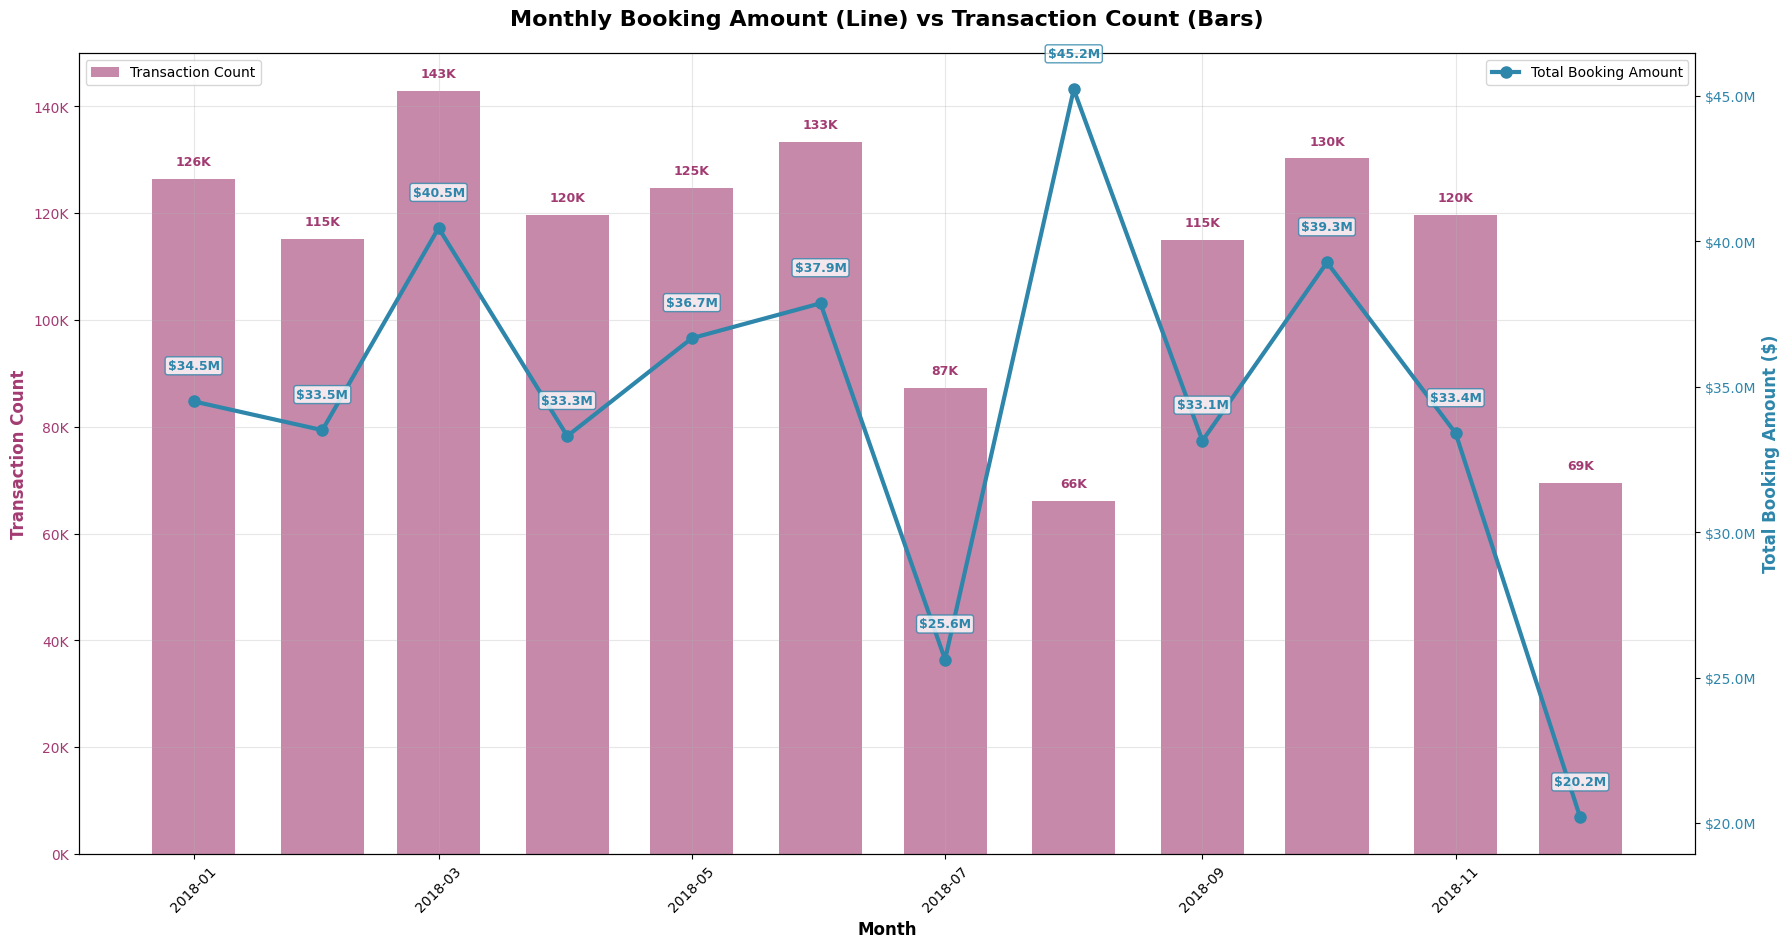

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a combined chart with booking amount as line and transactions as bars with data labels
fig, ax1 = plt.subplots(figsize=(18, 10))

# Create bar chart for transaction count
bars = ax1.bar(monthly_trends['date'], monthly_trends['TRANSACTION_COUNT'], 
               alpha=0.6, color='#A23B72', label='Transaction Count', width=20)

# Add data labels to bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'{height/1000:.0f}K', ha='center', va='bottom', 
             fontsize=9, fontweight='bold', color='#A23B72')

# Set up the first y-axis for transaction count
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Transaction Count', fontsize=12, fontweight='bold', color='#A23B72')
ax1.tick_params(axis='y', labelcolor='#A23B72')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

# Create second y-axis for booking amount
ax2 = ax1.twinx()
line = ax2.plot(monthly_trends['date'], monthly_trends['BOOKING_AMOUNT'], 
                color='#2E86AB', marker='o', linewidth=3, markersize=8, 
                label='Total Booking Amount')

# Add data labels to line chart
for i, (date, amount) in enumerate(zip(monthly_trends['date'], monthly_trends['BOOKING_AMOUNT'])):
    # Position labels above or below the line based on value
    if amount < 0:
        va = 'top'
        offset = -5000000
    else:
        va = 'bottom'
        offset = 1000000
    
    ax2.text(date, amount + offset, f'${amount/1e6:.1f}M', 
             ha='center', va=va, fontsize=9, fontweight='bold', 
             color='#2E86AB', bbox=dict(boxstyle='round,pad=0.2', 
             facecolor='white', alpha=0.8, edgecolor='#2E86AB'))

# Set up the second y-axis for booking amount
ax2.set_ylabel('Total Booking Amount ($)', fontsize=12, fontweight='bold', color='#2E86AB')
ax2.tick_params(axis='y', labelcolor='#2E86AB')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Formatting
ax1.set_title('Monthly Booking Amount (Line) vs Transaction Count (Bars)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')



# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [33]:
df.to_csv('cleaned_egencia_data.csv', index=False)

In [11]:


# Add derived columns for analysis
df['booking_year'] = df['BOOKING_DATE'].dt.year
df['booking_month'] = df['BOOKING_DATE'].dt.month
df['travel_duration'] = (df['TRAVEL_END'] - df['TRAVEL_START']).dt.days


# Ensure boolean column is properly typed
df['ONLINE_PURCHASE_FLAG'] = df['ONLINE_PURCHASE_FLAG'].astype(bool)

print("Data cleaning completed!")

print(f"Clean dataset : {len(df)} rows")


Data cleaning completed!
Clean dataset : 300000 rows


In [ ]:
# Data preprocessing and date conversion
df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'])
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'])
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'])

# Extract year-month for time series analysis
df['Year_Month'] = df['BOOKING_DATE'].dt.to_period('M')
df['Year'] = df['BOOKING_DATE'].dt.year
df['Quarter'] = df['BOOKING_DATE'].dt.quarter

# Basic statistics
print("Date range:", df['BOOKING_DATE'].min(), "to", df['BOOKING_DATE'].max())
print("Booking types:", df['BOOKING_TYPE_NAME'].value_counts())
print("Product types:", df['PRODUCT_NAME'].value_counts())
print("Platform distribution:", df['PLATFORM'].value_counts())